# Deep Residual Learning for Image Recognition - CIFAR-10 Experiment

This notebook demonstrates the key finding from the ResNet paper:
- **Degradation problem**: Deeper plain networks can have worse training error than shallow ones
- **Solution**: Residual connections enable optimization of very deep networks

We'll compare Plain networks vs ResNets at depths 20 and 56 on CIFAR-10.

## 1. Setup and Imports

In [1]:
import sys
from pathlib import Path

# Add parent directory to path for imports
sys.path.insert(0, str(Path.cwd().parent / 'src'))

import torch
import matplotlib.pyplot as plt
import numpy as np

from resnet_cifar10 import (
    ExperimentConfig,
    get_dataloaders,
    ResNetCIFAR,
    PlainNetCIFAR,
    train_model,
    evaluate,
    set_seed,
)

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.10.0+cu128
CUDA available: True
CUDA device: Tesla V100-DGXS-32GB


## 2. Configuration

We use a configuration-based approach for reproducibility and easy experimentation.

In [2]:
# Create configurations for different models
# For quick testing, use ExperimentConfig.quick_test(depth=20)
config = ExperimentConfig.default(depth=56)

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
config.train.device = device

# Set seed for reproducibility
set_seed(config.train.seed)

print(f"Using device: {device}")
print(f"\nExperiment Configuration:")
print(f"  Model depth: {config.model.depth}")
print(f"  Epochs: {config.train.epochs}")
print(f"  Batch size: {config.data.batch_size}")
print(f"  Learning rate: {config.train.lr}")
print(f"  Random seed: {config.train.seed}")

Using device: cuda

Experiment Configuration:
  Model depth: 56
  Epochs: 200
  Batch size: 128
  Learning rate: 0.1
  Random seed: 42


## 3. Load CIFAR-10 Data

CIFAR-10 consists of 60,000 32x32 color images in 10 classes:
- 50,000 training images
- 10,000 test images

We apply standard data augmentation: random crop with padding and horizontal flip.

In [3]:
# Load data
loaders = get_dataloaders(
    data_dir=config.data.data_dir,
    batch_size=config.data.batch_size,
    eval_batch_size=config.data.eval_batch_size,
    num_workers=config.data.num_workers,
    pin_memory=config.data.pin_memory,
)

train_loader = loaders['train']
test_loader = loaders['test']

print(f"Training batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")
print(f"Training samples: {len(train_loader.dataset)}")
print(f"Test samples: {len(test_loader.dataset)}")

100.0%


Training batches: 391
Test batches: 40
Training samples: 50000
Test samples: 10000


## 4. Visualize Sample Images

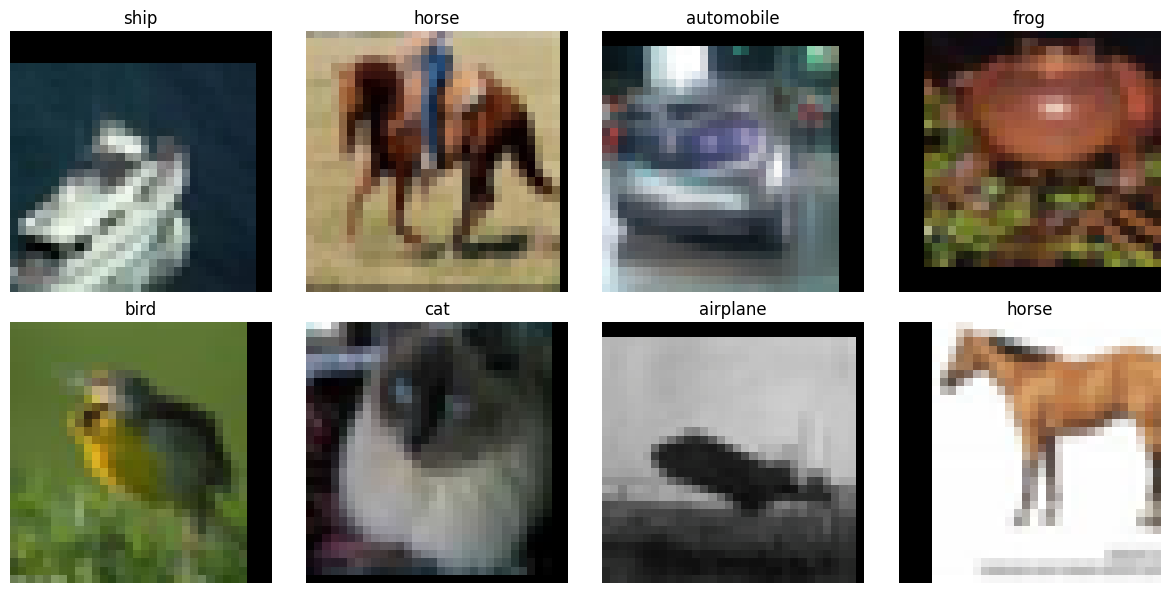

In [5]:
# Get a batch of training data
images, labels = next(iter(train_loader))

# CIFAR-10 class names
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

# Denormalize for visualization
mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
std = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)

def denormalize(img):
    return img * std + mean

# Plot first 8 images
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for idx, ax in enumerate(axes.flat):
    img = denormalize(images[idx]).permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    ax.set_title(f"{classes[labels[idx]]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

## 5. Model Architecture Comparison

Let's examine the difference between Plain and ResNet architectures.

In [6]:
# Create sample models
plain_20 = PlainNetCIFAR(depth=20)
resnet_20 = ResNetCIFAR(depth=20)

# Count parameters
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Model Comparison (depth=20):")
print(f"PlainNet-20 parameters: {count_parameters(plain_20):,}")
print(f"ResNet-20 parameters: {count_parameters(resnet_20):,}")
print(f"\nParameter difference: {count_parameters(resnet_20) - count_parameters(plain_20):,}")
print("\nNote: ResNet has slightly more parameters due to projection shortcuts.")

Model Comparison (depth=20):
PlainNet-20 parameters: 269,722
ResNet-20 parameters: 272,474

Parameter difference: 2,752

Note: ResNet has slightly more parameters due to projection shortcuts.


## 6. Experiment 1: PlainNet-20 (Shallow Plain Network)

In [7]:
# Create configuration and model
config_plain_20 = ExperimentConfig.default(depth=20)
config_plain_20.train.device = device
set_seed(config.train.seed)

plain_20 = PlainNetCIFAR(depth=20)
print(f"\nTraining PlainNet-20...")
print("=" * 80)

history_plain_20 = train_model(
    plain_20,
    train_loader,
    test_loader,
    config_plain_20.train,
    device,
    verbose=True,
)


Training PlainNet-20...
Epoch   1/200 | LR: 0.1000 | Train Loss: 1.744 Acc: 33.71% | Test Loss: 1.697 Acc: 39.05% | Best: 39.05%
Epoch  10/200 | LR: 0.1000 | Train Loss: 0.589 Acc: 79.76% | Test Loss: 0.777 Acc: 74.59% | Best: 75.35%
Epoch  20/200 | LR: 0.1000 | Train Loss: 0.446 Acc: 84.64% | Test Loss: 0.607 Acc: 79.90% | Best: 81.59%
Epoch  30/200 | LR: 0.1000 | Train Loss: 0.385 Acc: 86.73% | Test Loss: 0.784 Acc: 76.17% | Best: 83.57%
Epoch  40/200 | LR: 0.1000 | Train Loss: 0.351 Acc: 87.75% | Test Loss: 0.517 Acc: 83.56% | Best: 85.26%
Epoch  50/200 | LR: 0.1000 | Train Loss: 0.330 Acc: 88.51% | Test Loss: 0.428 Acc: 85.48% | Best: 85.48%
Epoch  60/200 | LR: 0.1000 | Train Loss: 0.313 Acc: 89.16% | Test Loss: 0.457 Acc: 84.91% | Best: 85.48%
Epoch  70/200 | LR: 0.1000 | Train Loss: 0.297 Acc: 89.59% | Test Loss: 0.464 Acc: 84.97% | Best: 85.48%
Epoch  80/200 | LR: 0.1000 | Train Loss: 0.290 Acc: 89.98% | Test Loss: 0.478 Acc: 84.90% | Best: 85.48%
Epoch  90/200 | LR: 0.1000 | T

## 7. Experiment 2: PlainNet-56 (Deep Plain Network)

According to the paper, this should show **degradation**: worse training error than PlainNet-20.

In [8]:
# Create configuration and model
config_plain_56 = ExperimentConfig.default(depth=56)
config_plain_56.train.device = device
set_seed(config.train.seed)

plain_56 = PlainNetCIFAR(depth=56)
print(f"\nTraining PlainNet-56...")
print("=" * 80)

history_plain_56 = train_model(
    plain_56,
    train_loader,
    test_loader,
    config_plain_56.train,
    device,
    verbose=True,
)


Training PlainNet-56...
Epoch   1/200 | LR: 0.1000 | Train Loss: 2.170 Acc: 16.95% | Test Loss: 2.167 Acc: 20.32% | Best: 20.32%
Epoch  10/200 | LR: 0.1000 | Train Loss: 1.490 Acc: 45.18% | Test Loss: 1.420 Acc: 46.95% | Best: 46.95%
Epoch  20/200 | LR: 0.1000 | Train Loss: 0.945 Acc: 66.84% | Test Loss: 0.983 Acc: 66.08% | Best: 66.08%
Epoch  30/200 | LR: 0.1000 | Train Loss: 0.762 Acc: 73.52% | Test Loss: 0.810 Acc: 72.79% | Best: 72.79%
Epoch  40/200 | LR: 0.1000 | Train Loss: 0.675 Acc: 76.76% | Test Loss: 0.805 Acc: 72.77% | Best: 73.87%
Epoch  50/200 | LR: 0.1000 | Train Loss: 0.635 Acc: 77.79% | Test Loss: 0.788 Acc: 72.69% | Best: 77.13%
Epoch  60/200 | LR: 0.1000 | Train Loss: 0.583 Acc: 79.81% | Test Loss: 1.026 Acc: 68.17% | Best: 77.13%
Epoch  70/200 | LR: 0.1000 | Train Loss: 0.567 Acc: 80.61% | Test Loss: 0.850 Acc: 73.18% | Best: 77.13%
Epoch  80/200 | LR: 0.1000 | Train Loss: 0.548 Acc: 81.22% | Test Loss: 0.872 Acc: 71.74% | Best: 77.13%
Epoch  90/200 | LR: 0.1000 | T

## 8. Experiment 3: ResNet-20 (Shallow Residual Network)

In [9]:
# Create configuration and model
config_resnet_20 = ExperimentConfig.default(depth=20)
config_resnet_20.train.device = device
set_seed(config.train.seed)

resnet_20 = ResNetCIFAR(depth=20)
print(f"\nTraining ResNet-20...")
print("=" * 80)

history_resnet_20 = train_model(
    resnet_20,
    train_loader,
    test_loader,
    config_resnet_20.train,
    device,
    verbose=True,
)


Training ResNet-20...
Epoch   1/200 | LR: 0.1000 | Train Loss: 1.563 Acc: 41.79% | Test Loss: 1.419 Acc: 50.06% | Best: 50.06%
Epoch  10/200 | LR: 0.1000 | Train Loss: 0.488 Acc: 83.17% | Test Loss: 0.569 Acc: 80.69% | Best: 80.69%
Epoch  20/200 | LR: 0.1000 | Train Loss: 0.357 Acc: 87.59% | Test Loss: 0.506 Acc: 83.59% | Best: 83.59%
Epoch  30/200 | LR: 0.1000 | Train Loss: 0.311 Acc: 89.09% | Test Loss: 0.488 Acc: 84.43% | Best: 86.19%
Epoch  40/200 | LR: 0.1000 | Train Loss: 0.284 Acc: 89.93% | Test Loss: 0.579 Acc: 82.26% | Best: 86.19%
Epoch  50/200 | LR: 0.1000 | Train Loss: 0.257 Acc: 91.10% | Test Loss: 0.475 Acc: 86.01% | Best: 86.90%
Epoch  60/200 | LR: 0.1000 | Train Loss: 0.245 Acc: 91.36% | Test Loss: 0.657 Acc: 80.79% | Best: 87.76%
Epoch  70/200 | LR: 0.1000 | Train Loss: 0.238 Acc: 91.60% | Test Loss: 0.451 Acc: 86.20% | Best: 87.86%
Epoch  80/200 | LR: 0.1000 | Train Loss: 0.229 Acc: 91.99% | Test Loss: 0.423 Acc: 86.81% | Best: 87.86%
Epoch  90/200 | LR: 0.1000 | Tra

## 9. Experiment 4: ResNet-56 (Deep Residual Network)

With residual connections, this should train **better** than ResNet-20.

In [ ]:
# Create configuration and model
config_resnet_56 = ExperimentConfig.default(depth=56)
config_resnet_56.train.device = device
set_seed(config.train.seed)

resnet_56 = ResNetCIFAR(depth=56)
print(f"\nTraining ResNet-56...")
print("=" * 80)

history_resnet_56 = train_model(
    resnet_56,
    train_loader,
    test_loader,
    config_resnet_56.train,
    device,
    verbose=True,
)


Training ResNet-56...
Epoch   1/200 | LR: 0.1000 | Train Loss: 1.925 Acc: 25.48% | Test Loss: 1.724 Acc: 35.04% | Best: 35.04%
Epoch  10/200 | LR: 0.1000 | Train Loss: 0.499 Acc: 82.73% | Test Loss: 0.709 Acc: 77.53% | Best: 77.53%
Epoch  20/200 | LR: 0.1000 | Train Loss: 0.335 Acc: 88.46% | Test Loss: 0.487 Acc: 84.46% | Best: 85.31%
Epoch  30/200 | LR: 0.1000 | Train Loss: 0.262 Acc: 90.82% | Test Loss: 0.449 Acc: 85.82% | Best: 86.32%
Epoch  40/200 | LR: 0.1000 | Train Loss: 0.228 Acc: 92.05% | Test Loss: 0.448 Acc: 86.60% | Best: 86.81%
Epoch  50/200 | LR: 0.1000 | Train Loss: 0.206 Acc: 92.68% | Test Loss: 0.581 Acc: 83.58% | Best: 88.72%
Epoch  60/200 | LR: 0.1000 | Train Loss: 0.189 Acc: 93.32% | Test Loss: 0.388 Acc: 88.19% | Best: 88.72%
Epoch  70/200 | LR: 0.1000 | Train Loss: 0.178 Acc: 93.74% | Test Loss: 0.419 Acc: 87.84% | Best: 88.72%
Epoch  80/200 | LR: 0.1000 | Train Loss: 0.169 Acc: 93.98% | Test Loss: 0.458 Acc: 86.43% | Best: 88.98%
Epoch  90/200 | LR: 0.1000 | Tra

## 10. Results Visualization

Let's compare all models to observe the degradation problem and how ResNets solve it.

In [ ]:
# Create comprehensive comparison plots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

epochs_range = range(1, config.train.epochs + 1)

# Training Loss
ax = axes[0, 0]
ax.plot(epochs_range, history_plain_20['train_loss'], label='PlainNet-20', linewidth=2)
ax.plot(epochs_range, history_plain_56['train_loss'], label='PlainNet-56', linewidth=2)
ax.plot(epochs_range, history_resnet_20['train_loss'], label='ResNet-20', linewidth=2, linestyle='--')
ax.plot(epochs_range, history_resnet_56['train_loss'], label='ResNet-56', linewidth=2, linestyle='--')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Training Loss', fontsize=12)
ax.set_title('Training Loss Comparison', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Training Accuracy
ax = axes[0, 1]
ax.plot(epochs_range, [acc*100 for acc in history_plain_20['train_acc']], label='PlainNet-20', linewidth=2)
ax.plot(epochs_range, [acc*100 for acc in history_plain_56['train_acc']], label='PlainNet-56', linewidth=2)
ax.plot(epochs_range, [acc*100 for acc in history_resnet_20['train_acc']], label='ResNet-20', linewidth=2, linestyle='--')
ax.plot(epochs_range, [acc*100 for acc in history_resnet_56['train_acc']], label='ResNet-56', linewidth=2, linestyle='--')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Training Accuracy (%)', fontsize=12)
ax.set_title('Training Accuracy Comparison', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Test Loss
ax = axes[1, 0]
ax.plot(epochs_range, history_plain_20['test_loss'], label='PlainNet-20', linewidth=2)
ax.plot(epochs_range, history_plain_56['test_loss'], label='PlainNet-56', linewidth=2)
ax.plot(epochs_range, history_resnet_20['test_loss'], label='ResNet-20', linewidth=2, linestyle='--')
ax.plot(epochs_range, history_resnet_56['test_loss'], label='ResNet-56', linewidth=2, linestyle='--')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Test Loss', fontsize=12)
ax.set_title('Test Loss Comparison', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Test Accuracy
ax = axes[1, 1]
ax.plot(epochs_range, [acc*100 for acc in history_plain_20['test_acc']], label='PlainNet-20', linewidth=2)
ax.plot(epochs_range, [acc*100 for acc in history_plain_56['test_acc']], label='PlainNet-56', linewidth=2)
ax.plot(epochs_range, [acc*100 for acc in history_resnet_20['test_acc']], label='ResNet-20', linewidth=2, linestyle='--')
ax.plot(epochs_range, [acc*100 for acc in history_resnet_56['test_acc']], label='ResNet-56', linewidth=2, linestyle='--')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('Test Accuracy Comparison', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 11. Key Observations

Let's quantify the degradation problem and ResNet's solution.

In [ ]:
# Final results summary
results = {
    'PlainNet-20': {
        'train_acc': history_plain_20['train_acc'][-1] * 100,
        'test_acc': history_plain_20['test_acc'][-1] * 100,
        'best_test_acc': max(history_plain_20['test_acc']) * 100
    },
    'PlainNet-56': {
        'train_acc': history_plain_56['train_acc'][-1] * 100,
        'test_acc': history_plain_56['test_acc'][-1] * 100,
        'best_test_acc': max(history_plain_56['test_acc']) * 100
    },
    'ResNet-20': {
        'train_acc': history_resnet_20['train_acc'][-1] * 100,
        'test_acc': history_resnet_20['test_acc'][-1] * 100,
        'best_test_acc': max(history_resnet_20['test_acc']) * 100
    },
    'ResNet-56': {
        'train_acc': history_resnet_56['train_acc'][-1] * 100,
        'test_acc': history_resnet_56['test_acc'][-1] * 100,
        'best_test_acc': max(history_resnet_56['test_acc']) * 100
    }
}

print("\n" + "="*80)
print("FINAL RESULTS SUMMARY")
print("="*80)

for model_name, metrics in results.items():
    print(f"\n{model_name}:")
    print(f"  Final Train Accuracy: {metrics['train_acc']:.2f}%")
    print(f"  Final Test Accuracy:  {metrics['test_acc']:.2f}%")
    print(f"  Best Test Accuracy:   {metrics['best_test_acc']:.2f}%")

print("\n" + "="*80)
print("KEY FINDINGS")
print("="*80)

# Degradation in Plain networks
plain_degradation = results['PlainNet-20']['train_acc'] - results['PlainNet-56']['train_acc']
print(f"\n1. DEGRADATION PROBLEM (Plain Networks):")
print(f"   PlainNet-56 trains WORSE than PlainNet-20 by {plain_degradation:.2f}% (training acc)")
print(f"   This demonstrates the degradation problem mentioned in the paper.")

# ResNet scaling benefit
resnet_improvement = results['ResNet-56']['test_acc'] - results['ResNet-20']['test_acc']
print(f"\n2. RESIDUAL LEARNING FIXES OPTIMIZATION (ResNets):")
print(f"   ResNet-56 achieves {resnet_improvement:.2f}% better test accuracy than ResNet-20")
print(f"   Deeper ResNets train better, as expected.")

# Overall best model
best_model = max(results.items(), key=lambda x: x[1]['best_test_acc'])
print(f"\n3. BEST MODEL:")
print(f"   {best_model[0]} with {best_model[1]['best_test_acc']:.2f}% test accuracy")

print("\n" + "="*80)

## 12. Conclusion

This experiment demonstrates the core contribution of the ResNet paper:

1. **Degradation Problem**: Plain networks suffer from optimization difficulties as depth increases. PlainNet-56 has worse training error than PlainNet-20.

2. **Residual Learning Solution**: Skip connections make it easier to optimize very deep networks. ResNet-56 trains better than ResNet-20.

3. **Depth Pays Off**: With proper residual connections, deeper networks consistently achieve better accuracy.

The residual connections allow gradients to flow more directly through the network, making it easier for SGD to find good solutions even at extreme depths (the paper shows this works up to 1000+ layers on CIFAR-10).

## 13. Optional: Save Models and Results

In [ ]:
import json
from pathlib import Path

# Create results directory
results_dir = Path('results')
results_dir.mkdir(exist_ok=True)

# Save training histories
histories = {
    'plain_20': history_plain_20,
    'plain_56': history_plain_56,
    'resnet_20': history_resnet_20,
    'resnet_56': history_resnet_56
}

# Convert to JSON-serializable format
for name, history in histories.items():
    serializable_history = {k: [float(v) for v in vals] for k, vals in history.items()}
    with open(results_dir / f'{name}_history.json', 'w') as f:
        json.dump(serializable_history, f, indent=2)

# Save model checkpoints (optional - can be large)
# torch.save(resnet_56.state_dict(), results_dir / 'resnet_56_best.pth')

print(f"Results saved to {results_dir}")